In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)

In [2]:
setwd("./04fig3/")

In [3]:
sp <- readRDS("./merge_red.RDS")

In [4]:
m <- as.data.frame(unique(sp@meta.data$sample))
rownames(m) <- m[,1]
colnames(m) <- "group"
m$group <- substr(m$group,1,3)
m$batch <- c("1","1","1","1","2","2","2","2","2","2","2")
m$group <- str_replace(m$group,"Sha","Sham")
m$sample <- rownames(m)
m

,group,batch,sample
,<chr>,<chr>,<chr>
Sham2,Sham,1,Sham2
Sham1,Sham,1,Sham1
RIR2,RIR,1,RIR2
RIR1,RIR,1,RIR1
RIR3,RIR,2,RIR3
Sham4,Sham,2,Sham4
RIR4,RIR,2,RIR4
RIR5,RIR,2,RIR5
Sham5,Sham,2,Sham5


In [5]:
sp@meta.data$batch <- "NA"
for(i in unique(m$sample)){
    sp@meta.data[which(sp@meta.data$sample==i),]$batch <- m[which(m$sample==i),]$batch
}

In [ ]:
library(sva)
library(limma)

In [7]:
sp <- ScaleData(sp)

Centering and scaling data matrix



In [303]:
sp

An object of class Seurat 
24382 features across 145127 samples within 1 assay 
Active assay: RNA (24382 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [9]:
###fig1 deg
area <- c("GCL","Optic nerve","Cornea&conj","INL","Len","ONL","Iris","CB","Muscle","RPE")

In [10]:
Idents(sp) <- as.factor(sp@meta.data$group)
n=0
for(i in area){
    n=n+1
    sp1 <- subset(sp,subset =area==i)
    sp1 <- ScaleData(sp1, features = rownames(sp1))
    deg <- FindMarkers(sp1,`ident.1` = "RIR",`ident.2` = "Sham",slot = "scale.data")
    deg$divi_area <- i
    deg$gene <- rownames(deg)
    if(n==1){
        deg1 <- deg
    }
    else{
        deg1 <- rbind(deg1,deg)
    }
}

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix



In [11]:
colnames(deg1) <- str_replace(colnames(deg1),"divi_area","cluster")

In [297]:
deg2 <- deg1[which(abs(deg1$avg_log2FC)>1.5&deg1$p_val_adj<0.05),]
table(deg2$cluster)


         CB Cornea&conj         GCL         INL        Iris         Len 
        102         146         434          99         101         223 
     Muscle         ONL Optic nerve         RPE 
         13          35         157           8 

In [3]:
deg2 <- readRDS("deg.RDS")

In [ ]:
deg3 <- deg2[which(deg2$cluster=="GCL"&deg2$`pct.1`>0.02),]
deg3

In [108]:
####GSEA
library(GseaVis)

In [115]:
deg1 <-deg3

In [116]:
df_id <- bitr(deg1$gene,
              fromType  = "SYMBOL",
              toType = "ENTREZID",
              OrgDb = "org.Mm.eg.db")
deg1$SYMBOL <- deg1$gene
df_all<-merge(deg1,df_id,by="SYMBOL",all=F)
df_all_sort <- df_all[order(df_all$avg_log2FC, decreasing = T),]

'select()' returned 1:1 mapping between keys and columns



In [117]:
gene_fc = df_all_sort$avg_log2FC #把foldchange按照从大到小提取出来
head(gene_fc)

[1] 10.802288  6.280155  6.129395  5.945143  5.718799  5.641010

In [118]:
names(gene_fc) <- df_all_sort$ENTREZID

In [120]:
gsea_GO <- gseGO(geneList= gene_fc,
              OrgDb= org.Mm.eg.db,
              ont= "BP",
                minGSSize    = 5,
                maxGSSize    = 500,
                pvalueCutoff = 0.05,
                verbose   = FALSE)

In [122]:
ego3 <- gsea_GO

In [123]:
ego3<- setReadable(ego3,
                     OrgDb= org.Mm.eg.db,
                     keyType= "ENTREZID")

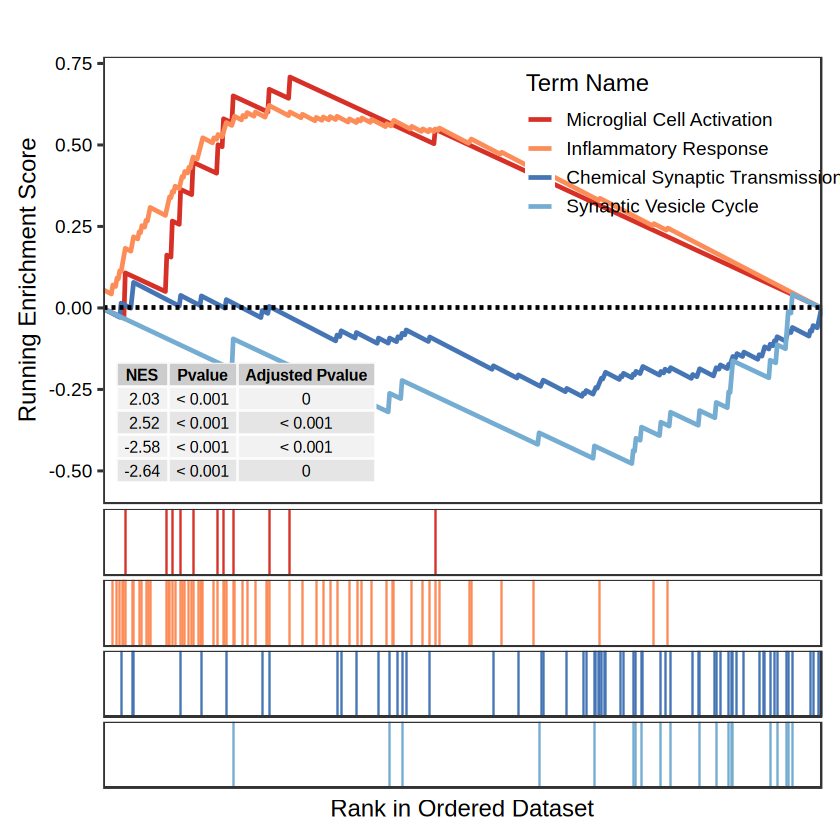

In [170]:
gseaNb(object = ego3,
                 geneSetID = c("GO:0001774","GO:0006954","GO:0007268","GO:0099504"),
                 subPlot = 2, 
       addPval = T, 
       pvalX = 0.02, pvalY = -0.05,
       rmHt = T,
       termWidth = 30,
       base_size = 14, 
       legend.position = c(0.8,0.8),
       curveCol = c("#D73027","#FC8D59","#4575B4","#74ADD1")
      )
ggsave("GSEA_multi.pdf",width = 8,height = 8)